# 01 Failure Case Taxonomy

This notebook starts the explainability study by classifying model mistakes.

The goal is to answer:

> What kinds of failures does the crack segmentation model make, and are those failures related to other defects, shadows, seams, or low-confidence cracks?

This is not fully manual labeling. It is a **semi-automatic taxonomy**:

1. Use model predictions to measure FP, FN, TP.
2. Use original multi-class masks to detect overlap with non-crack labels.
3. Use image statistics and component geometry to propose shadow/edge/seam-like labels.
4. Export a review table so you can manually validate only the most important examples.

Known original mask values from the dataset code:

- `40`: crack
- `160`: water-like defect / non-crack defect
- `200`: leaching-like defect / non-crack defect

The exact semantic names should be verified against your dataset documentation, but these values are useful for detecting whether crack false positives overlap other annotated defects.

## 1. Setup

Choose one model and one setting first. After the workflow looks reasonable, rerun for all three settings.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from PIL import Image
from scipy import ndimage
import cv2
from IPython.display import display, Markdown
from fastai.vision.all import imagenet_stats

def find_project_root(start: Path = Path.cwd()) -> Path:
    for path in [start.resolve(), *start.resolve().parents]:
        if (path / 'baseline_models_scripts').exists() and (path / 'TACK_Tunnel_Data').exists():
            return path
    raise FileNotFoundError('Could not find CSCI5527-final project root')

PROJECT_ROOT = find_project_root()
RUNS_DIR = PROJECT_ROOT / 'baseline_models_scripts' / 'runs'
MODELS_DIR = RUNS_DIR / 'models'
OUTPUT_DIR = PROJECT_ROOT / 'analysis' / 'explainability_suite' / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sys.path.append(str(PROJECT_ROOT))
sys.path.append(str(PROJECT_ROOT / 'baseline_models_scripts'))

from train_ttd import build_model, baseline_model_pipeline, EXPERIMENTS

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
DEVICE


device(type='cuda', index=0)

In [2]:
SETTING = 'Single-TB'

MODEL_CFG = {
#     'label': 'Unet-efficientnet-b0',
    'label': 'Unet-resnet34',
    'arch': 'Unet',
#     'encoder': 'efficientnet-b0',
    'encoder': 'resnet34',
    'weights': 'imagenet',
}

RAW_MASK_VALUES = {
    'crack': 40,
    'water_or_noncrack_defect': 160,
    'leaching_or_noncrack_defect': 200,
}

# For a two-class softmax model, argmax is equivalent to threshold=0.50.
# After running the threshold sweep below, set this to the best validation/test threshold
# and rerun the taxonomy cells to see the adjusted failure profile.
DECISION_THRESHOLD = 0.50

SETTING, MODEL_CFG, DECISION_THRESHOLD


('Single-TB',
 {'label': 'Unet-resnet34',
  'arch': 'Unet',
  'encoder': 'resnet34',
  'weights': 'imagenet'},
 0.5)

## 2. Load Dataloader and Model

In [3]:
train_dl, val_dl, test_dl, custom_stats, df_test_ready = baseline_model_pipeline(
    base_dir=PROJECT_ROOT,
    dict_files=EXPERIMENTS[SETTING],
    bs=4,
    img_size=512,
)

model_name = f"{MODEL_CFG['arch']}-{MODEL_CFG['encoder']}-{MODEL_CFG['weights']}_{SETTING}"
ckpt_path = MODELS_DIR / f'{model_name}.pth'
model = build_model(MODEL_CFG['arch'], MODEL_CFG['encoder'], MODEL_CFG['weights'], classes=2)
model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
model.to(DEVICE).eval()

display(Markdown(f'Loaded `{model_name}`'))
display(Markdown(f'Test rows: **{len(df_test_ready)}**'))

Loading CSV metadata...
Sanitizing training and validation masks...


Sanitizing Masks: 100%|██████████| 424/424 [00:00<00:00, 1325.32it/s]


Sanitizing test masks...


Sanitizing Masks: 100%|██████████| 48/48 [00:00<00:00, 1177.50it/s]


Generating Dataloaders...

Pipeline Ready:
 - Training batches: 82
 - Validation batches: 24
 - Testing batches: 12


Loaded `Unet-resnet34-imagenet_Single-TB`

Test rows: **48**

## 3. Path Helpers for Original Multi-Class Masks

The training pipeline converts the original masks into binary crack masks. For failure taxonomy, we also want the original masks because false positives may overlap other annotated defect categories.

In [4]:
def original_mask_path_from_image_path(image_path):
    image_path = Path(image_path)
    img_name = image_path.stem
    parts = img_name.rsplit('_', 1)
    if len(parts) == 2:
        mask_name = f'{parts[0]}_fuse_{parts[1]}_1band.png'
    else:
        mask_name = f'{img_name}.png'
    return PROJECT_ROOT / 'TACK_Tunnel_Data' / '3_mask' / mask_name


df_test_ready = df_test_ready.copy().reset_index(drop=True)
df_test_ready['raw_mask_path'] = df_test_ready['image_abs_path'].apply(original_mask_path_from_image_path)
display(df_test_ready[['image_abs_path', 'mask_path_sanitized', 'raw_mask_path']].head())
display(Markdown(f"Raw masks found: **{df_test_ready['raw_mask_path'].apply(lambda p: p.exists()).sum()} / {len(df_test_ready)}**"))

,image_abs_path,mask_path_sanitized,raw_mask_path
0,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_img/TB_Camera7_000012_E.png,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_masks_sanitized/TB_Camera7_000012_fuse_E_1band.png,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_mask/TB_Camera7_000012_fuse_E_1band.png
1,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_img/TB_Camera3_001107_H.png,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_masks_sanitized/TB_Camera3_001107_fuse_H_1band.png,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_mask/TB_Camera3_001107_fuse_H_1band.png
2,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_img/TB_Camera4_000334_N.png,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_masks_sanitized/TB_Camera4_000334_fuse_N_1band.png,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_mask/TB_Camera4_000334_fuse_N_1band.png
3,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_img/TB_Camera5_000894_E.png,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_masks_sanitized/TB_Camera5_000894_fuse_E_1band.png,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_mask/TB_Camera5_000894_fuse_E_1band.png
4,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_img/TB_Camera9_000558_N.png,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_masks_sanitized/TB_Camera9_000558_fuse_N_1band.png,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_mask/TB_Camera9_000558_fuse_N_1band.png


Raw masks found: **48 / 48**

## 4. Explanation and Failure Feature Functions

These functions compute scientific signals for taxonomy:

- pixel-level FP/FN/TP counts
- crack probability on GT and FP regions
- entropy uncertainty
- overlap between FP and other original mask classes
- component geometry: number of components, area, elongation
- image cues: brightness and edge strength near FP/FN regions

The result is a candidate label, not final truth. Human review is still needed for the final report examples.

In [5]:
def denorm_image(img, custom_stats=None):
    stats = custom_stats if custom_stats else imagenet_stats
    mean = torch.tensor(stats[0], device='cpu').view(3, 1, 1)
    std = torch.tensor(stats[1], device='cpu').view(3, 1, 1)
    arr = (img.detach().cpu() * std + mean).permute(1, 2, 0).numpy()
    return np.clip(arr, 0, 1)


def predict_batch(model, images, threshold=None):
    if threshold is None:
        threshold = DECISION_THRESHOLD
    with torch.no_grad():
        logits = model(images.to(DEVICE))
        probs = torch.softmax(logits, dim=1)
    crack_prob = probs[:, 1].detach().cpu().numpy()
    pred = (crack_prob >= threshold).astype(np.uint8)
    return crack_prob, pred


def binary_entropy(prob, eps=1e-6):
    prob = np.asarray(prob, dtype=np.float64)
    prob = np.clip(prob, eps, 1 - eps)
    ent = -(prob * np.log(prob) + (1 - prob) * np.log(1 - prob))
    return ent / np.log(2.0)


def resize_nearest(arr, shape):
    if arr.shape == shape:
        return arr
    return cv2.resize(arr.astype(np.uint8), (shape[1], shape[0]), interpolation=cv2.INTER_NEAREST)


def load_raw_mask(row, target_shape):
    path = Path(row['raw_mask_path'])
    if not path.exists():
        return np.zeros(target_shape, dtype=np.uint8)
    raw = np.array(Image.open(path))
    return resize_nearest(raw, target_shape)


def region_mean(arr, region):
    if region.sum() == 0:
        return np.nan
    return float(arr[region].mean())


def component_geometry(mask):
    labels, n = ndimage.label(mask)
    rows = []
    for label_id in range(1, n + 1):
        ys, xs = np.where(labels == label_id)
        area = len(xs)
        if area < 2:
            elongation = np.nan
        else:
            coords = np.column_stack([xs, ys]).astype(float)
            cov = np.cov(coords, rowvar=False)
            eigvals = np.linalg.eigvalsh(cov)
            elongation = float((eigvals[-1] + 1e-8) / (eigvals[0] + 1e-8))
        rows.append({'area': area, 'elongation': elongation})
    if not rows:
        return {'n_components': 0, 'largest_area': 0, 'max_elongation': np.nan, 'mean_area': 0}
    df = pd.DataFrame(rows)
    return {
        'n_components': int(len(df)),
        'largest_area': int(df['area'].max()),
        'max_elongation': float(df['elongation'].max()),
        'mean_area': float(df['area'].mean()),
    }


def make_error_rgb(pred, target):
    pred = pred.astype(bool)
    target = target.astype(bool)
    rgb = np.zeros((*target.shape, 3), dtype=float)
    rgb[pred & target] = [0, 1, 0]
    rgb[(~pred) & target] = [1, 0, 0]
    rgb[pred & (~target)] = [1, 1, 0]
    return rgb


def image_name_from_path(path):
    return Path(path).name


In [6]:
def classify_candidate(row):
    labels = []
    if row['fn_pixels'] > 100 and row['mean_prob_on_gt'] < 0.35:
        labels.append('missed_low_confidence_crack')
    if row['fn_pixels'] > 100 and row['gt_components'] >= 3:
        labels.append('fragmented_or_thin_crack')
    if row['fp_pixels'] > 100 and row['fp_overlap_noncrack_ratio'] >= 0.25:
        labels.append('fp_overlaps_other_defect_mask')
    if row['fp_pixels'] > 100 and row['fp_brightness'] < row['image_brightness'] - 0.08:
        labels.append('fp_dark_shadow_candidate')
    if row['fp_pixels'] > 100 and row['fp_edge_strength'] > row['image_edge_strength'] * 1.5:
        labels.append('fp_edge_or_seam_candidate')
    if row['fp_pixels'] > 100 and row['pred_max_elongation'] > 20:
        labels.append('fp_long_linear_structure_candidate')
    if row['tp_pixels'] > 100 and row['fp_pixels'] > row['tp_pixels'] * 0.5:
        labels.append('over_thick_or_oversegmented_prediction')
    if not labels and row['iou'] >= 0.50:
        labels.append('good_or_acceptable_prediction')
    if not labels:
        labels.append('mixed_or_unclear_failure')
    return ', '.join(labels)


def sample_failure_features(sample_id, image_tensor, target, prob, pred, raw_mask):
    target = target.astype(bool)
    pred_bool = pred.astype(bool)
    tp = pred_bool & target
    fp = pred_bool & (~target)
    fn = (~pred_bool) & target

    img = denorm_image(image_tensor, custom_stats)
    gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY).astype(float) / 255.0
    sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    edge = np.sqrt(sobel_x ** 2 + sobel_y ** 2)

    water_mask = raw_mask == RAW_MASK_VALUES['water_or_noncrack_defect']
    leaching_mask = raw_mask == RAW_MASK_VALUES['leaching_or_noncrack_defect']
    noncrack_defect = water_mask | leaching_mask

    tp_pixels = int(tp.sum())
    fp_pixels = int(fp.sum())
    fn_pixels = int(fn.sum())
    precision = tp_pixels / (tp_pixels + fp_pixels + 1e-8)
    recall = tp_pixels / (tp_pixels + fn_pixels + 1e-8)
    iou = tp_pixels / (tp_pixels + fp_pixels + fn_pixels + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    pred_geo = component_geometry(pred_bool)
    gt_geo = component_geometry(target)

    row = {
        'sample_id': sample_id,
        'gt_pixels': int(target.sum()),
        'pred_pixels': int(pred_bool.sum()),
        'tp_pixels': tp_pixels,
        'fp_pixels': fp_pixels,
        'fn_pixels': fn_pixels,
        'iou': iou,
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'mean_prob_on_gt': region_mean(prob, target),
        'mean_prob_on_fp': region_mean(prob, fp),
        'mean_uncertainty': float(binary_entropy(prob).mean()),
        'image_brightness': float(gray.mean()),
        'fp_brightness': region_mean(gray, fp),
        'fn_brightness': region_mean(gray, fn),
        'image_edge_strength': float(edge.mean()),
        'fp_edge_strength': region_mean(edge, fp),
        'fn_edge_strength': region_mean(edge, fn),
        'fp_overlap_water_pixels': int((fp & water_mask).sum()),
        'fp_overlap_leaching_pixels': int((fp & leaching_mask).sum()),
        'fp_overlap_noncrack_ratio': int((fp & noncrack_defect).sum()) / (fp_pixels + 1e-8),
        'pred_components': pred_geo['n_components'],
        'pred_largest_area': pred_geo['largest_area'],
        'pred_max_elongation': pred_geo['max_elongation'],
        'gt_components': gt_geo['n_components'],
        'gt_largest_area': gt_geo['largest_area'],
        'gt_max_elongation': gt_geo['max_elongation'],
    }
    row['candidate_failure_type'] = classify_candidate(row)
    return row

## 5. Build the Failure Taxonomy Table

This cell runs inference over the test set and creates a table with candidate failure labels.

In [7]:
MAX_BATCHES = None

rows = []
threshold_cache = []
sample_id = 0
for batch_idx, (images, masks) in enumerate(test_dl):
    if MAX_BATCHES is not None and batch_idx >= MAX_BATCHES:
        break
    probs, preds = predict_batch(model, images)
    targets = masks.squeeze(1).cpu().numpy() if masks.ndim == 4 else masks.cpu().numpy()

    for i in range(images.shape[0]):
        if sample_id >= len(df_test_ready):
            break
        row_meta = df_test_ready.iloc[sample_id]
        raw_mask = load_raw_mask(row_meta, targets[i].shape)
        row = sample_failure_features(sample_id, images[i], targets[i], probs[i], preds[i], raw_mask)
        row['image_name'] = image_name_from_path(row_meta['image_abs_path'])
        row['image_abs_path'] = row_meta['image_abs_path']
        row['raw_mask_path'] = str(row_meta['raw_mask_path'])
        row['decision_threshold'] = DECISION_THRESHOLD
        row['setting'] = SETTING
        row['model_name'] = model_name
        threshold_cache.append({
            'sample_id': sample_id,
            'image_name': row['image_name'],
            'prob': probs[i].copy(),
            'target': targets[i].astype(bool).copy(),
        })
        rows.append(row)
        sample_id += 1

taxonomy_df = pd.DataFrame(rows)
taxonomy_path = OUTPUT_DIR / f'failure_taxonomy_{model_name}.csv'
taxonomy_df.to_csv(taxonomy_path, index=False)

display(Markdown(f'Saved taxonomy table to `{taxonomy_path}`'))
display(taxonomy_df.head())


Saved taxonomy table to `/users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/failure_taxonomy_Unet-resnet34-imagenet_Single-TB.csv`

,sample_id,gt_pixels,pred_pixels,tp_pixels,fp_pixels,fn_pixels,iou,f1,precision,recall,...,gt_components,gt_largest_area,gt_max_elongation,candidate_failure_type,image_name,image_abs_path,raw_mask_path,decision_threshold,setting,model_name
0,0,0,17,0,17,0,0.0,0.0,0.0,0.0,...,0,0,NaN,mixed_or_unclear_failure,TB_Camera7_000012_E.png,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_img/TB_Camera7_000012_E.png,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_mask/TB_Camera7_000012_fuse_E_1band.png,0.5,Single-TB,Unet-resnet34-imagenet_Single-TB
1,1,0,0,0,0,0,0.0,0.0,0.0,0.0,...,0,0,NaN,mixed_or_unclear_failure,TB_Camera3_001107_H.png,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_img/TB_Camera3_001107_H.png,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_mask/TB_Camera3_001107_fuse_H_1band.png,0.5,Single-TB,Unet-resnet34-imagenet_Single-TB
2,2,0,0,0,0,0,0.0,0.0,0.0,0.0,...,0,0,NaN,mixed_or_unclear_failure,TB_Camera4_000334_N.png,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_img/TB_Camera4_000334_N.png,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_mask/TB_Camera4_000334_fuse_N_1band.png,0.5,Single-TB,Unet-resnet34-imagenet_Single-TB
3,3,0,0,0,0,0,0.0,0.0,0.0,0.0,...,0,0,NaN,mixed_or_unclear_failure,TB_Camera5_000894_E.png,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_img/TB_Camera5_000894_E.png,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_mask/TB_Camera5_000894_fuse_E_1band.png,0.5,Single-TB,Unet-resnet34-imagenet_Single-TB
4,4,0,202,0,202,0,0.0,0.0,0.0,0.0,...,0,0,NaN,"fp_dark_shadow_candidate, fp_long_linear_structure_candidate",TB_Camera9_000558_N.png,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_img/TB_Camera9_000558_N.png,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_mask/TB_Camera9_000558_fuse_N_1band.png,0.5,Single-TB,Unet-resnet34-imagenet_Single-TB


## 6. Threshold Sweep for IoU/F1

The default two-class prediction uses `DECISION_THRESHOLD = 0.50`. This sweep checks whether a stricter or looser crack-probability threshold improves IoU/F1. If a better threshold appears, set `DECISION_THRESHOLD` near that value and rerun the taxonomy cells.


In [8]:
# def metrics_from_counts(tp, fp, fn):
#     precision = tp / (tp + fp + 1e-8)
#     recall = tp / (tp + fn + 1e-8)
#     iou = tp / (tp + fp + fn + 1e-8)
#     f1 = 2 * precision * recall / (precision + recall + 1e-8)
#     return iou, f1, precision, recall


# def evaluate_threshold_cache(threshold_cache, thresholds=np.arange(0.10, 0.91, 0.05)):
#     rows = []
#     for threshold in thresholds:
#         tp = fp = fn = 0
#         per_sample_iou = []
#         per_sample_f1 = []
#         empty_gt_fp_images = 0
#         missed_gt_positive_images = 0
#         for item in threshold_cache:
#             pred = item['prob'] >= threshold
#             target = item['target']
#             s_tp = int((pred & target).sum())
#             s_fp = int((pred & ~target).sum())
#             s_fn = int((~pred & target).sum())
#             s_iou, s_f1, _, _ = metrics_from_counts(s_tp, s_fp, s_fn)
#             per_sample_iou.append(s_iou)
#             per_sample_f1.append(s_f1)
#             tp += s_tp
#             fp += s_fp
#             fn += s_fn
#             empty_gt_fp_images += int(target.sum() == 0 and pred.sum() > 0)
#             missed_gt_positive_images += int(target.sum() > 0 and pred.sum() == 0)
#         micro_iou, micro_f1, micro_precision, micro_recall = metrics_from_counts(tp, fp, fn)
#         rows.append({
#             'threshold': round(float(threshold), 2),
#             'micro_iou': micro_iou,
#             'micro_f1': micro_f1,
#             'micro_precision': micro_precision,
#             'micro_recall': micro_recall,
#             'mean_sample_iou': float(np.mean(per_sample_iou)),
#             'mean_sample_f1': float(np.mean(per_sample_f1)),
#             'fp_pixels': fp,
#             'fn_pixels': fn,
#             'empty_gt_fp_images': empty_gt_fp_images,
#             'missed_gt_positive_images': missed_gt_positive_images,
#         })
#     return pd.DataFrame(rows)


# threshold_sweep_df = evaluate_threshold_cache(threshold_cache)
# threshold_sweep_path = OUTPUT_DIR / f'threshold_sweep_{model_name}.csv'
# threshold_sweep_df.to_csv(threshold_sweep_path, index=False)

# best_micro_f1 = threshold_sweep_df.sort_values('micro_f1', ascending=False).iloc[0]
# best_micro_iou = threshold_sweep_df.sort_values('micro_iou', ascending=False).iloc[0]

# best_f1_msg = (
#     f"Best micro-F1 threshold: **{best_micro_f1['threshold']:.2f}** "
#     f"(IoU={best_micro_f1['micro_iou']:.3f}, F1={best_micro_f1['micro_f1']:.3f}, "
#     f"precision={best_micro_f1['micro_precision']:.3f}, recall={best_micro_f1['micro_recall']:.3f})"
# )
# best_iou_msg = (
#     f"Best micro-IoU threshold: **{best_micro_iou['threshold']:.2f}** "
#     f"(IoU={best_micro_iou['micro_iou']:.3f}, F1={best_micro_iou['micro_f1']:.3f}, "
#     f"precision={best_micro_iou['micro_precision']:.3f}, recall={best_micro_iou['micro_recall']:.3f})"
# )

# display(Markdown(f'Saved threshold sweep to `{threshold_sweep_path}`'))
# display(Markdown(best_f1_msg))
# display(Markdown(best_iou_msg))
# display(threshold_sweep_df.sort_values('micro_f1', ascending=False).head(10))


## 6. Summarize Candidate Failure Types

Because one sample can receive multiple candidate labels, this cell counts labels after splitting the comma-separated field.

In [9]:
label_counts = (
    taxonomy_df['candidate_failure_type']
    .str.split(', ')
    .explode()
    .value_counts()
    .rename_axis('candidate_failure_type')
    .reset_index(name='count')
)

display(label_counts)

display(Markdown('### Worst IoU examples'))
display(taxonomy_df.sort_values('iou').head(10)[[
    'image_name', 'sample_id', 'iou', 'f1', 'precision', 'recall', 'gt_pixels', 'pred_pixels',
    'fp_pixels', 'fn_pixels', 'candidate_failure_type', 'image_abs_path'
]])


,candidate_failure_type,count
0,fp_long_linear_structure_candidate,22
1,mixed_or_unclear_failure,20
2,over_thick_or_oversegmented_prediction,15
3,fp_dark_shadow_candidate,14
4,fp_edge_or_seam_candidate,13
5,fragmented_or_thin_crack,12
6,missed_low_confidence_crack,6


### Worst IoU examples

,image_name,sample_id,iou,f1,precision,recall,gt_pixels,pred_pixels,fp_pixels,fn_pixels,candidate_failure_type,image_abs_path
0,TB_Camera7_000012_E.png,0,0.0,0.0,0.0,0.0,0,17,17,0,mixed_or_unclear_failure,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_img/TB_Camera7_000012_E.png
21,TB_Camera7_000298_C.png,21,0.0,0.0,0.0,0.0,0,512,512,0,"fp_dark_shadow_candidate, fp_long_linear_structure_candidate",/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_img/TB_Camera7_000298_C.png
22,TB_Camera5_001185_N.png,22,0.0,0.0,0.0,0.0,0,11,11,0,mixed_or_unclear_failure,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_img/TB_Camera5_001185_N.png
46,TB_Camera6_001021_B.png,46,0.0,0.0,0.0,0.0,0,0,0,0,mixed_or_unclear_failure,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_img/TB_Camera6_001021_B.png
25,TB_Camera5_000766_E.png,25,0.0,0.0,0.0,0.0,0,55,55,0,mixed_or_unclear_failure,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_img/TB_Camera5_000766_E.png
26,TB_Camera5_000850_F.png,26,0.0,0.0,0.0,0.0,0,0,0,0,mixed_or_unclear_failure,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_img/TB_Camera5_000850_F.png
29,TB_Camera8_001935_I.png,29,0.0,0.0,0.0,0.0,0,180,180,0,fp_dark_shadow_candidate,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_img/TB_Camera8_001935_I.png
18,TB_Camera9_001684_N.png,18,0.0,0.0,0.0,0.0,568,0,0,568,missed_low_confidence_crack,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_img/TB_Camera9_001684_N.png
31,TB_Camera3_000902_E.png,31,0.0,0.0,0.0,0.0,0,24,24,0,mixed_or_unclear_failure,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_img/TB_Camera3_000902_E.png
35,TB_Camera4_001502_H.png,35,0.0,0.0,0.0,0.0,0,0,0,0,mixed_or_unclear_failure,/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_img/TB_Camera4_001502_H.png


## 7. Focused View: `fragmented_or_thin_crack`

This section prints the samples that match `fragmented_or_thin_crack` so you can use Single-TB as a concrete example in your report.

In [10]:
fragmented_df = taxonomy_df[
    taxonomy_df['candidate_failure_type'].str.contains('fragmented_or_thin_crack', regex=False, na=False)
].copy()

cols = [
    'sample_id',
    'image_name',
    'iou',
    'f1',
    'precision',
    'recall',
    'fp_pixels',
    'fn_pixels',
    'candidate_failure_type',
    'image_abs_path',
]

print(f'Single-TB fragmented_or_thin_crack samples: {len(fragmented_df)} / {len(taxonomy_df)}')
display(fragmented_df.sort_values(['fn_pixels', 'iou'], ascending=[False, True])[cols])

Single-TB fragmented_or_thin_crack samples: 12 / 48


,sample_id,image_name,iou,f1,precision,recall,fp_pixels,fn_pixels,candidate_failure_type,image_abs_path
10,10,TB_Camera5_000894_B.png,0.069799,0.130490,0.325914,0.081576,424,2308,"missed_low_confidence_crack, fragmented_or_thin_crack, fp_edge_or_seam_candidate, fp_long_linear_structure_candidate, over_thick_or_oversegmented_prediction",/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_img/TB_Camera5_000894_B.png
33,33,TB_Camera4_000034_L.png,0.695272,0.820248,0.836874,0.804270,1843,2301,"fragmented_or_thin_crack, fp_dark_shadow_candidate, fp_edge_or_seam_candidate, fp_long_linear_structure_candidate",/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_img/TB_Camera4_000034_L.png
19,19,TB_Camera4_001527_M.png,0.313761,0.477653,0.747065,0.351053,237,1294,"missed_low_confidence_crack, fragmented_or_thin_crack, fp_long_linear_structure_candidate",/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_img/TB_Camera4_001527_M.png
6,6,TB_Camera9_000558_I.png,0.356052,0.525131,0.607442,0.462465,422,759,"fragmented_or_thin_crack, fp_dark_shadow_candidate, fp_edge_or_seam_candidate, fp_long_linear_structure_candidate, over_thick_or_oversegmented_prediction",/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_img/TB_Camera9_000558_I.png
43,43,TB_Camera4_001620_M.png,0.203485,0.338160,0.301443,0.385063,920,634,"fragmented_or_thin_crack, fp_long_linear_structure_candidate, over_thick_or_oversegmented_prediction",/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_img/TB_Camera4_001620_M.png
30,30,TB_Camera3_000211_L.png,0.572755,0.728346,0.655835,0.818886,1165,491,"fragmented_or_thin_crack, fp_dark_shadow_candidate, fp_edge_or_seam_candidate, fp_long_linear_structure_candidate, over_thick_or_oversegmented_prediction",/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_img/TB_Camera3_000211_L.png
42,42,TB_Camera3_001107_L.png,0.521084,0.685149,0.636497,0.741852,494,301,"fragmented_or_thin_crack, fp_dark_shadow_candidate, fp_edge_or_seam_candidate, fp_long_linear_structure_candidate, over_thick_or_oversegmented_prediction",/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_img/TB_Camera3_001107_L.png
28,28,TB_Camera4_001493_I.png,0.361793,0.531348,0.508246,0.556650,328,270,"fragmented_or_thin_crack, fp_long_linear_structure_candidate, over_thick_or_oversegmented_prediction",/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_img/TB_Camera4_001493_I.png
15,15,TB_Camera9_000409_H.png,0.374687,0.545124,0.417736,0.784293,1044,206,"fragmented_or_thin_crack, fp_dark_shadow_candidate, fp_edge_or_seam_candidate, fp_long_linear_structure_candidate, over_thick_or_oversegmented_prediction",/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_img/TB_Camera9_000409_H.png
39,39,TB_Camera8_000597_I.png,0.000000,0.000000,0.000000,0.000000,0,199,"missed_low_confidence_crack, fragmented_or_thin_crack",/users/7/yu001011/csci5527/CSCI5527-final/TACK_Tunnel_Data/3_img/TB_Camera8_000597_I.png


## 8. Show Three Representative `fragmented_or_thin_crack` Examples

This section shows three examples with the original image, ground truth, prediction, and overlap map so you can use them directly in the report.

Selected sample_ids: [30, 15]


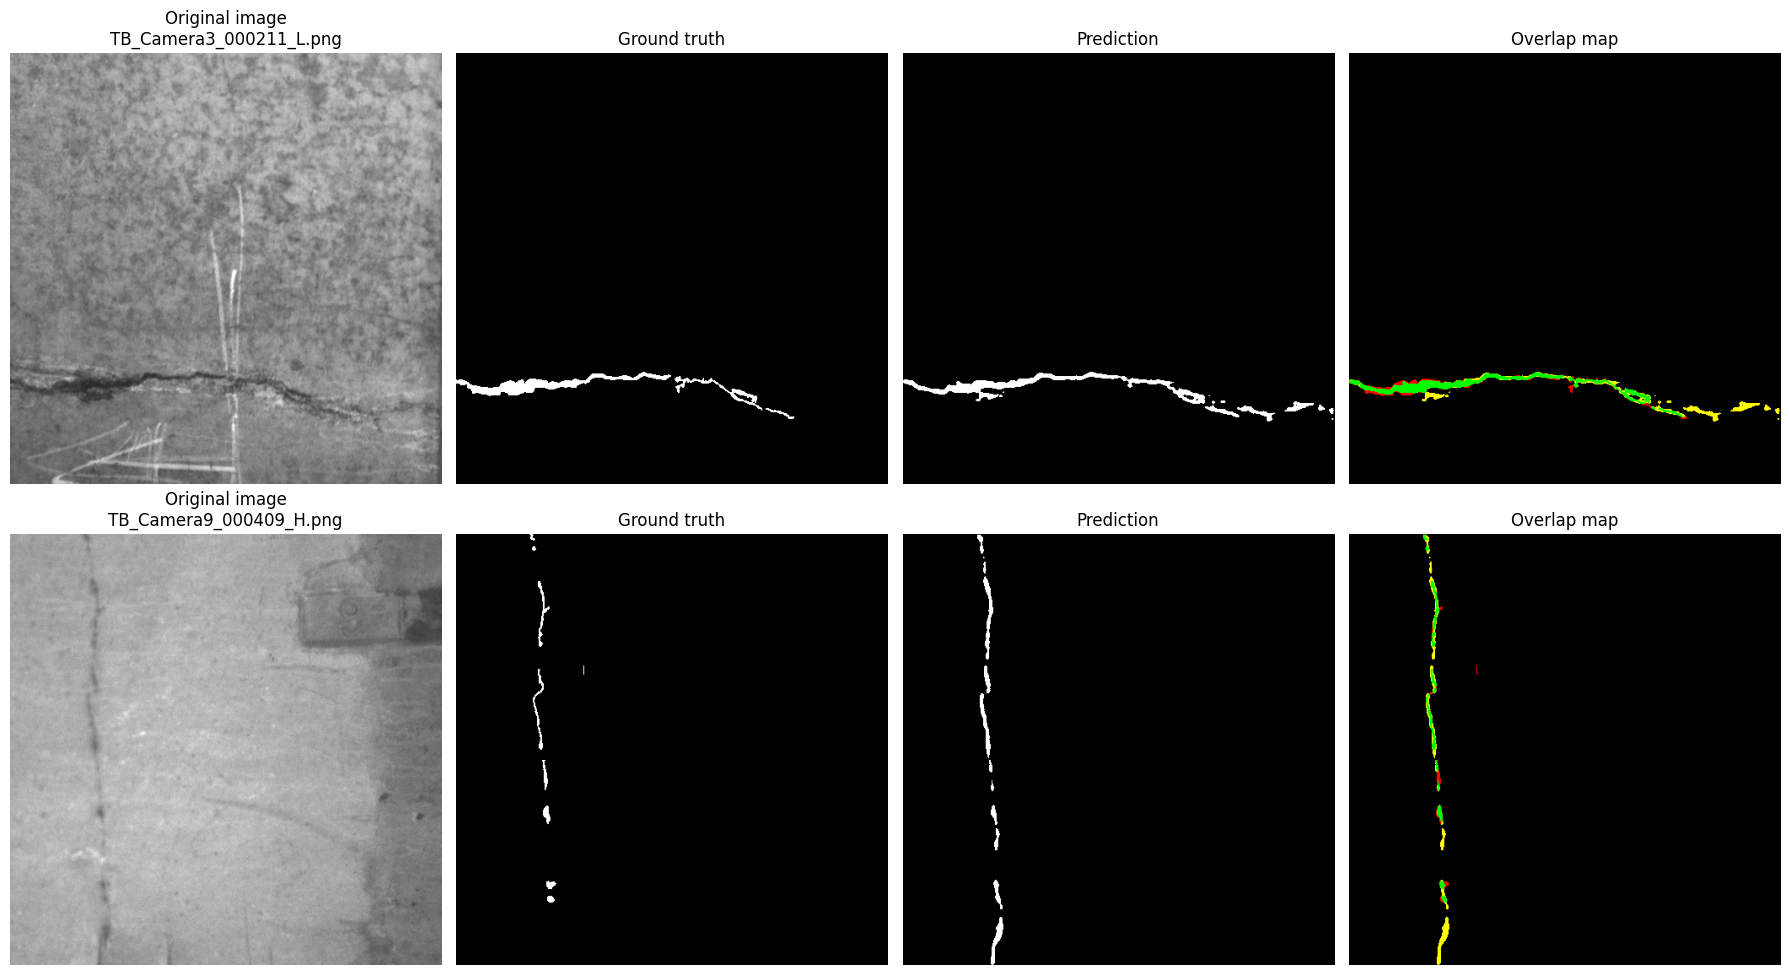

In [23]:
if 'taxonomy_df' not in globals():
    taxonomy_path = OUTPUT_DIR / f'failure_taxonomy_{model_name}.csv'
    taxonomy_df = pd.read_csv(taxonomy_path)


def get_prediction_for_sample(sample_id):
    wanted = int(sample_id)
    current = 0
    for images, masks in test_dl:
        if current + images.shape[0] > wanted:
            i = wanted - current
            prob, pred = predict_batch(model, images[i:i+1])
            img_vis = denorm_image(images[i], custom_stats)
            target = masks[i].squeeze().cpu().numpy().astype(np.uint8)
            raw_mask = load_raw_mask(df_test_ready.iloc[wanted], target.shape)
            return img_vis, target, raw_mask, prob[0], pred[0]
        current += images.shape[0]
    raise IndexError(sample_id)


def show_fragmented_examples(sample_ids, max_items=3):
    sample_ids = list(sample_ids)[:max_items]
    if not sample_ids:
        print('No fragmented_or_thin_crack samples found.')
        return

    fig, axes = plt.subplots(len(sample_ids), 4, figsize=(18, 5 * len(sample_ids)))
    if len(sample_ids) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_idx, sample_id in enumerate(sample_ids):
        img_vis, target, raw_mask, prob, pred = get_prediction_for_sample(sample_id)
        overlap = make_error_rgb(pred, target)
        row = taxonomy_df[taxonomy_df['sample_id'].eq(int(sample_id))].iloc[0]

        axes[row_idx, 0].imshow(img_vis)
        axes[row_idx, 0].set_title(f"Original image\n{row['image_name']}")
        axes[row_idx, 1].imshow(target, cmap='gray')
        axes[row_idx, 1].set_title('Ground truth')
        axes[row_idx, 2].imshow(pred, cmap='gray')
        axes[row_idx, 2].set_title('Prediction')
        axes[row_idx, 3].imshow(overlap)
        axes[row_idx, 3].set_title('Overlap map')

        for col_idx in range(4):
            axes[row_idx, col_idx].axis('off')

    plt.tight_layout()
    plt.show()


# Manually specify which samples to display by image name or sample_id
# Option 1: Specify by image names
# image_names = [
#     'TB_Camera5_000894_B.png',
#     'TB_Camera4_000034_L.png',
#     'TB_Camera4_001527_M.png',
# ]

# # Convert image names to sample_ids
# selected_ids = []
# for img_name in image_names:
#     matches = taxonomy_df[taxonomy_df['image_name'].eq(img_name)]['sample_id'].tolist()
#     if matches:
#         selected_ids.extend(matches)
#     else:
#         print(f'Warning: Image "{img_name}" not found in taxonomy.')

# Option 2 (alternative): Specify sample_ids directly
selected_ids = [30, 15]

print('Selected sample_ids:', selected_ids)
show_fragmented_examples(selected_ids, max_items=3)

##  Visual Review Panels

Use this section to inspect examples from a candidate failure type.

Manual review is still important, but it is now targeted. You only inspect examples that the scientific signals identified as important.

In [12]:
def load_sample_by_id(sample_id):
    # Reconstruct sample from dataframe paths so review is independent of dataloader ordering.
    row = df_test_ready.iloc[int(sample_id)]
    img = Image.open(row['image_abs_path']).convert('RGB').resize((512, 512))
    gt = Image.open(row['mask_path_sanitized']).resize((512, 512), resample=Image.Resampling.NEAREST)
    raw = Image.open(row['raw_mask_path']).resize((512, 512), resample=Image.Resampling.NEAREST) if Path(row['raw_mask_path']).exists() else Image.fromarray(np.zeros((512, 512), dtype=np.uint8))
    return np.array(img) / 255.0, np.array(gt).astype(np.uint8), np.array(raw).astype(np.uint8), row


def review_sample(sample_id):
    # For exact model input normalization, use dataloader version when possible.
    wanted = int(sample_id)
    current = 0
    for images, masks in test_dl:
        if current + images.shape[0] > wanted:
            i = wanted - current
            prob, pred = predict_batch(model, images[i:i+1])
            img_vis = denorm_image(images[i], custom_stats)
            target = masks[i].squeeze().cpu().numpy().astype(np.uint8)
            raw_mask = load_raw_mask(df_test_ready.iloc[wanted], target.shape)
            break
        current += images.shape[0]
    else:
        raise IndexError(sample_id)

    prob = prob[0]
    pred = pred[0]
    entropy = binary_entropy(prob)
    error_rgb = make_error_rgb(pred, target)
    other_defect = np.isin(raw_mask, [RAW_MASK_VALUES['water_or_noncrack_defect'], RAW_MASK_VALUES['leaching_or_noncrack_defect']])

    fig, ax = plt.subplots(1, 7, figsize=(28, 4))
    fig.suptitle(f'sample_id={sample_id}', fontsize=14)
    ax[0].imshow(img_vis); ax[0].set_title('Image')
    ax[1].imshow(target, cmap='gray'); ax[1].set_title('GT crack')
    ax[2].imshow(pred, cmap='gray'); ax[2].set_title('Prediction')
    ax[3].imshow(img_vis); ax[3].imshow(prob, cmap='jet', alpha=0.45); ax[3].set_title('Crack prob')
    ax[4].imshow(img_vis); ax[4].imshow(entropy, cmap='magma', alpha=0.45); ax[4].set_title('Uncertainty')
    ax[5].imshow(error_rgb); ax[5].set_title('TP/FN/FP')
    ax[6].imshow(img_vis); ax[6].imshow(other_defect, cmap='cool', alpha=0.45); ax[6].set_title('Other raw masks')
    for a in ax:
        a.axis('off')
    plt.tight_layout()
    plt.show()

    display(taxonomy_df[taxonomy_df['sample_id'].eq(sample_id)].T)


failure_type_to_review = 'fp_overlaps_other_defect_mask'
review_ids = taxonomy_df[taxonomy_df['candidate_failure_type'].str.contains(failure_type_to_review, regex=False)].sort_values('fp_pixels', ascending=False)['sample_id'].head(3).tolist()
review_ids

[]

In [13]:
for sid in review_ids:
    review_sample(int(sid))

##  Create a Human Audit Sheet

This is where manual work enters, but only after automatic ranking.

Recommended audit process:

1. Pick top 5-10 examples per candidate failure type.
2. Review the visual panels.
3. Fill `human_failure_type` and `notes` in the CSV.
4. Use the audited subset as evidence in the report.

The full dataset does not need to be manually labeled.

In [14]:
audit_candidates = []
for failure_type in label_counts['candidate_failure_type']:
    subset = taxonomy_df[taxonomy_df['candidate_failure_type'].str.contains(failure_type, regex=False)].copy()
    if subset.empty:
        continue
    subset = subset.sort_values(['fp_pixels', 'fn_pixels'], ascending=False).head(8)
    subset['review_target_type'] = failure_type
    audit_candidates.append(subset)

audit_df = pd.concat(audit_candidates, ignore_index=True).drop_duplicates('image_name')
audit_df['human_failure_type'] = ''
audit_df['notes'] = ''

audit_path = OUTPUT_DIR / f'failure_taxonomy_audit_sheet_{model_name}.csv'
audit_first_cols = ['image_name', 'review_target_type', 'candidate_failure_type', 'iou', 'f1', 'precision', 'recall', 'fp_pixels', 'fn_pixels', 'human_failure_type', 'notes']
audit_df = audit_df[audit_first_cols + [c for c in audit_df.columns if c not in audit_first_cols and c != 'sample_id'] + ['sample_id']]
audit_df.to_csv(audit_path, index=False)

display(Markdown(f'Saved audit sheet to `{audit_path}`'))
display(audit_df[['image_name', 'review_target_type', 'candidate_failure_type', 'iou', 'fp_pixels', 'fn_pixels', 'human_failure_type', 'notes']].head(20))


Saved audit sheet to `/users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/failure_taxonomy_audit_sheet_Unet-resnet34-imagenet_Single-TB.csv`

,image_name,review_target_type,candidate_failure_type,iou,fp_pixels,fn_pixels,human_failure_type,notes
0,TB_Camera4_000034_L.png,fp_long_linear_structure_candidate,"fragmented_or_thin_crack, fp_dark_shadow_candidate, fp_edge_or_seam_candidate, fp_long_linear_structure_candidate",0.695272,1843,2301,,
1,TB_Camera6_000020_H.png,fp_long_linear_structure_candidate,"fragmented_or_thin_crack, fp_dark_shadow_candidate, fp_edge_or_seam_candidate, fp_long_linear_structure_candidate, over_thick_or_oversegmented_prediction",0.340944,1191,108,,
2,TB_Camera3_000211_L.png,fp_long_linear_structure_candidate,"fragmented_or_thin_crack, fp_dark_shadow_candidate, fp_edge_or_seam_candidate, fp_long_linear_structure_candidate, over_thick_or_oversegmented_prediction",0.572755,1165,491,,
3,TB_Camera9_000409_H.png,fp_long_linear_structure_candidate,"fragmented_or_thin_crack, fp_dark_shadow_candidate, fp_edge_or_seam_candidate, fp_long_linear_structure_candidate, over_thick_or_oversegmented_prediction",0.374687,1044,206,,
4,TB_Camera5_001225_M.png,fp_long_linear_structure_candidate,"fp_long_linear_structure_candidate, over_thick_or_oversegmented_prediction",0.187457,977,215,,
5,TB_Camera4_001620_M.png,fp_long_linear_structure_candidate,"fragmented_or_thin_crack, fp_long_linear_structure_candidate, over_thick_or_oversegmented_prediction",0.203485,920,634,,
6,TB_Camera7_000389_F.png,fp_long_linear_structure_candidate,"fragmented_or_thin_crack, fp_dark_shadow_candidate, fp_edge_or_seam_candidate, fp_long_linear_structure_candidate, over_thick_or_oversegmented_prediction",0.564993,817,110,,
7,TB_Camera9_000326_F.png,fp_long_linear_structure_candidate,"fp_edge_or_seam_candidate, fp_long_linear_structure_candidate, over_thick_or_oversegmented_prediction",0.310656,784,57,,
8,TB_Camera9_001684_G.png,mixed_or_unclear_failure,mixed_or_unclear_failure,0.000000,79,0,,
9,TB_Camera4_001627_G.png,mixed_or_unclear_failure,mixed_or_unclear_failure,0.000000,68,27,,


##  Export Representative Failure Panels

This section turns the automatic taxonomy into report-ready visual evidence.

Each exported panel includes:

- original image
- binary crack ground truth
- model prediction
- crack probability map
- uncertainty map
- TP/FN/FP error map
- original non-crack defect mask overlay, if available

The candidate labels are still heuristic labels, so use these figures for targeted manual review before making final claims.

In [15]:
# Failure types to export as representative review figures.
# These are the main categories observed in the Single-TB run.
REPORT_FAILURE_TYPES = [
    'fp_long_linear_structure_candidate',
    'fp_edge_or_seam_candidate',
    'fp_dark_shadow_candidate',
    'fragmented_or_thin_crack',
    'missed_low_confidence_crack',
    'over_thick_or_oversegmented_prediction',
    'mixed_or_unclear_failure',
]

FAILURE_TYPE_DESCRIPTIONS = {
    'fp_long_linear_structure_candidate': 'FP components are long and thin, suggesting confusion with linear crack-like structures.',
    'fp_edge_or_seam_candidate': 'FP regions have high edge response, suggesting confusion with seams or strong boundaries.',
    'fp_dark_shadow_candidate': 'FP regions are darker than the image average, suggesting shadow-like confusion.',
    'fragmented_or_thin_crack': 'GT crack has multiple components and many FN pixels, suggesting missed thin or fragmented cracks.',
    'missed_low_confidence_crack': 'GT crack exists but model probability on GT crack is low.',
    'over_thick_or_oversegmented_prediction': 'Model overlaps crack but predicts too much surrounding area.',
    'mixed_or_unclear_failure': 'No single automatic rule explains the sample clearly.',
}

FIGURE_DIR = OUTPUT_DIR / f'representative_failure_panels_{model_name}'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def candidate_sort_columns(failure_type):
    if failure_type in {'fragmented_or_thin_crack', 'missed_low_confidence_crack'}:
        return ['fn_pixels', 'gt_pixels', 'fp_pixels'], [False, False, False]
    if failure_type == 'mixed_or_unclear_failure':
        return ['iou', 'fp_pixels', 'fn_pixels'], [True, False, False]
    if failure_type == 'over_thick_or_oversegmented_prediction':
        return ['fp_pixels', 'tp_pixels'], [False, False]
    return ['fp_pixels', 'pred_pixels', 'fn_pixels'], [False, False, False]


def select_representative_samples(taxonomy_df, failure_types, n_per_type=3):
    rows = []
    for failure_type in failure_types:
        subset = taxonomy_df[
            taxonomy_df['candidate_failure_type'].str.contains(failure_type, regex=False, na=False)
        ].copy()
        if subset.empty:
            rows.append({
                'failure_type': failure_type,
                'image_name': None,
                'sample_id': None,
                'rank_within_type': None,
                'note': 'No samples matched this candidate type.',
            })
            continue
        sort_cols, ascending = candidate_sort_columns(failure_type)
        subset = subset.sort_values(sort_cols, ascending=ascending).head(n_per_type)
        for rank, (_, row) in enumerate(subset.iterrows(), start=1):
            rows.append({
                'failure_type': failure_type,
                'image_name': row['image_name'],
                'sample_id': int(row['sample_id']),
                'rank_within_type': rank,
                'iou': row['iou'],
                'f1': row['f1'],
                'precision': row['precision'],
                'recall': row['recall'],
                'fp_pixels': int(row['fp_pixels']),
                'fn_pixels': int(row['fn_pixels']),
                'candidate_failure_type': row['candidate_failure_type'],
                'description': FAILURE_TYPE_DESCRIPTIONS.get(failure_type, ''),
                'note': '',
            })
    return pd.DataFrame(rows)


representative_df = select_representative_samples(taxonomy_df, REPORT_FAILURE_TYPES, n_per_type=3)
representative_path = OUTPUT_DIR / f'representative_failure_samples_{model_name}.csv'
representative_df.to_csv(representative_path, index=False)

display(Markdown(f'Saved representative sample list to `{representative_path}`'))
display(representative_df)


Saved representative sample list to `/users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/representative_failure_samples_Unet-resnet34-imagenet_Single-TB.csv`

,failure_type,image_name,sample_id,rank_within_type,iou,f1,precision,recall,fp_pixels,fn_pixels,candidate_failure_type,description,note
0,fp_long_linear_structure_candidate,TB_Camera4_000034_L.png,33,1,0.695272,0.820248,0.836874,0.804270,1843,2301,"fragmented_or_thin_crack, fp_dark_shadow_candidate, fp_edge_or_seam_candidate, fp_long_linear_structure_candidate","FP components are long and thin, suggesting confusion with linear crack-like structures.",
1,fp_long_linear_structure_candidate,TB_Camera6_000020_H.png,8,2,0.340944,0.508513,0.360709,0.861538,1191,108,"fragmented_or_thin_crack, fp_dark_shadow_candidate, fp_edge_or_seam_candidate, fp_long_linear_structure_candidate, over_thick_or_oversegmented_prediction","FP components are long and thin, suggesting confusion with linear crack-like structures.",
2,fp_long_linear_structure_candidate,TB_Camera3_000211_L.png,30,3,0.572755,0.728346,0.655835,0.818886,1165,491,"fragmented_or_thin_crack, fp_dark_shadow_candidate, fp_edge_or_seam_candidate, fp_long_linear_structure_candidate, over_thick_or_oversegmented_prediction","FP components are long and thin, suggesting confusion with linear crack-like structures.",
3,fp_edge_or_seam_candidate,TB_Camera4_000034_L.png,33,1,0.695272,0.820248,0.836874,0.804270,1843,2301,"fragmented_or_thin_crack, fp_dark_shadow_candidate, fp_edge_or_seam_candidate, fp_long_linear_structure_candidate","FP regions have high edge response, suggesting confusion with seams or strong boundaries.",
4,fp_edge_or_seam_candidate,TB_Camera6_000020_H.png,8,2,0.340944,0.508513,0.360709,0.861538,1191,108,"fragmented_or_thin_crack, fp_dark_shadow_candidate, fp_edge_or_seam_candidate, fp_long_linear_structure_candidate, over_thick_or_oversegmented_prediction","FP regions have high edge response, suggesting confusion with seams or strong boundaries.",
5,fp_edge_or_seam_candidate,TB_Camera3_000211_L.png,30,3,0.572755,0.728346,0.655835,0.818886,1165,491,"fragmented_or_thin_crack, fp_dark_shadow_candidate, fp_edge_or_seam_candidate, fp_long_linear_structure_candidate, over_thick_or_oversegmented_prediction","FP regions have high edge response, suggesting confusion with seams or strong boundaries.",
6,fp_dark_shadow_candidate,TB_Camera4_000034_L.png,33,1,0.695272,0.820248,0.836874,0.804270,1843,2301,"fragmented_or_thin_crack, fp_dark_shadow_candidate, fp_edge_or_seam_candidate, fp_long_linear_structure_candidate","FP regions are darker than the image average, suggesting shadow-like confusion.",
7,fp_dark_shadow_candidate,TB_Camera6_000020_H.png,8,2,0.340944,0.508513,0.360709,0.861538,1191,108,"fragmented_or_thin_crack, fp_dark_shadow_candidate, fp_edge_or_seam_candidate, fp_long_linear_structure_candidate, over_thick_or_oversegmented_prediction","FP regions are darker than the image average, suggesting shadow-like confusion.",
8,fp_dark_shadow_candidate,TB_Camera3_000211_L.png,30,3,0.572755,0.728346,0.655835,0.818886,1165,491,"fragmented_or_thin_crack, fp_dark_shadow_candidate, fp_edge_or_seam_candidate, fp_long_linear_structure_candidate, over_thick_or_oversegmented_prediction","FP regions are darker than the image average, suggesting shadow-like confusion.",
9,fragmented_or_thin_crack,TB_Camera5_000894_B.png,10,1,0.069799,0.130490,0.325914,0.081576,424,2308,"missed_low_confidence_crack, fragmented_or_thin_crack, fp_edge_or_seam_candidate, fp_long_linear_structure_candidate, over_thick_or_oversegmented_prediction","GT crack has multiple components and many FN pixels, suggesting missed thin or fragmented cracks.",


## Save Report-Ready Panels

Run this cell to save one PNG panel per selected representative sample. The filenames include the failure type, rank, and sample id.

In [16]:
def safe_name(text):
    return ''.join(ch if ch.isalnum() or ch in {'-', '_'} else '_' for ch in str(text))


def get_prediction_for_sample(sample_id):
    wanted = int(sample_id)
    current = 0
    for images, masks in test_dl:
        if current + images.shape[0] > wanted:
            i = wanted - current
            prob, pred = predict_batch(model, images[i:i+1])
            img_vis = denorm_image(images[i], custom_stats)
            target = masks[i].squeeze().cpu().numpy().astype(np.uint8)
            raw_mask = load_raw_mask(df_test_ready.iloc[wanted], target.shape)
            return img_vis, target, raw_mask, prob[0], pred[0]
        current += images.shape[0]
    raise IndexError(sample_id)


def save_failure_panel(sample_id, failure_type, rank_within_type=None, show=False):
    img_vis, target, raw_mask, prob, pred = get_prediction_for_sample(sample_id)
    entropy = binary_entropy(prob)
    error_rgb = make_error_rgb(pred, target)
    other_defect = np.isin(
        raw_mask,
        [RAW_MASK_VALUES['water_or_noncrack_defect'], RAW_MASK_VALUES['leaching_or_noncrack_defect']],
    )
    row = taxonomy_df[taxonomy_df['sample_id'].eq(int(sample_id))].iloc[0]

    image_name = row.get('image_name', f'sample{int(sample_id):03d}')
    title = (
        f"{failure_type} | {image_name} | sample {sample_id} | "
        f"IoU={row['iou']:.3f}, F1={row['f1']:.3f}, "
        f"FP={int(row['fp_pixels'])}, FN={int(row['fn_pixels'])}"
    )

    fig, ax = plt.subplots(1, 7, figsize=(28, 4))
    fig.suptitle(title, fontsize=13)
    ax[0].imshow(img_vis); ax[0].set_title('Image')
    ax[1].imshow(target, cmap='gray'); ax[1].set_title('GT crack')
    ax[2].imshow(pred, cmap='gray'); ax[2].set_title('Prediction')
    ax[3].imshow(img_vis); ax[3].imshow(prob, cmap='jet', alpha=0.45); ax[3].set_title('Crack prob')
    ax[4].imshow(img_vis); ax[4].imshow(entropy, cmap='magma', alpha=0.45); ax[4].set_title('Uncertainty')
    ax[5].imshow(error_rgb); ax[5].set_title('TP green / FN red / FP yellow')
    ax[6].imshow(img_vis); ax[6].imshow(other_defect, cmap='cool', alpha=0.45); ax[6].set_title('Other raw masks')
    for a in ax:
        a.axis('off')
    plt.tight_layout()

    rank_part = f'rank{int(rank_within_type):02d}_' if pd.notna(rank_within_type) else ''
    out_path = FIGURE_DIR / f"{safe_name(failure_type)}_{rank_part}{safe_name(image_name)}.png"
    fig.savefig(out_path, dpi=180, bbox_inches='tight')
    if show:
        plt.show()
    else:
        plt.close(fig)
    return out_path


saved_panel_rows = []
for _, row in representative_df.dropna(subset=['sample_id']).iterrows():
    out_path = save_failure_panel(
        sample_id=int(row['sample_id']),
        failure_type=row['failure_type'],
        rank_within_type=row['rank_within_type'],
        show=False,
    )
    saved_panel_rows.append({
        'failure_type': row['failure_type'],
        'image_name': row['image_name'],
        'sample_id': int(row['sample_id']),
        'rank_within_type': int(row['rank_within_type']),
        'figure_path': str(out_path),
    })

saved_panels_df = pd.DataFrame(saved_panel_rows)
saved_panels_path = OUTPUT_DIR / f'representative_failure_panel_paths_{model_name}.csv'
saved_panels_df.to_csv(saved_panels_path, index=False)

display(Markdown(f'Saved **{len(saved_panels_df)}** representative panels to `{FIGURE_DIR}`'))
display(saved_panels_df)


Saved **21** representative panels to `/users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/representative_failure_panels_Unet-resnet34-imagenet_Single-TB`

,failure_type,image_name,sample_id,rank_within_type,figure_path
0,fp_long_linear_structure_candidate,TB_Camera4_000034_L.png,33,1,/users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/representative_failure_panels_Unet-resnet34-imagenet_Single-TB/fp_long_linear_structure_candidate_rank01_TB_Camera4_000034_L_png.png
1,fp_long_linear_structure_candidate,TB_Camera6_000020_H.png,8,2,/users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/representative_failure_panels_Unet-resnet34-imagenet_Single-TB/fp_long_linear_structure_candidate_rank02_TB_Camera6_000020_H_png.png
2,fp_long_linear_structure_candidate,TB_Camera3_000211_L.png,30,3,/users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/representative_failure_panels_Unet-resnet34-imagenet_Single-TB/fp_long_linear_structure_candidate_rank03_TB_Camera3_000211_L_png.png
3,fp_edge_or_seam_candidate,TB_Camera4_000034_L.png,33,1,/users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/representative_failure_panels_Unet-resnet34-imagenet_Single-TB/fp_edge_or_seam_candidate_rank01_TB_Camera4_000034_L_png.png
4,fp_edge_or_seam_candidate,TB_Camera6_000020_H.png,8,2,/users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/representative_failure_panels_Unet-resnet34-imagenet_Single-TB/fp_edge_or_seam_candidate_rank02_TB_Camera6_000020_H_png.png
5,fp_edge_or_seam_candidate,TB_Camera3_000211_L.png,30,3,/users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/representative_failure_panels_Unet-resnet34-imagenet_Single-TB/fp_edge_or_seam_candidate_rank03_TB_Camera3_000211_L_png.png
6,fp_dark_shadow_candidate,TB_Camera4_000034_L.png,33,1,/users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/representative_failure_panels_Unet-resnet34-imagenet_Single-TB/fp_dark_shadow_candidate_rank01_TB_Camera4_000034_L_png.png
7,fp_dark_shadow_candidate,TB_Camera6_000020_H.png,8,2,/users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/representative_failure_panels_Unet-resnet34-imagenet_Single-TB/fp_dark_shadow_candidate_rank02_TB_Camera6_000020_H_png.png
8,fp_dark_shadow_candidate,TB_Camera3_000211_L.png,30,3,/users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/representative_failure_panels_Unet-resnet34-imagenet_Single-TB/fp_dark_shadow_candidate_rank03_TB_Camera3_000211_L_png.png
9,fragmented_or_thin_crack,TB_Camera5_000894_B.png,10,1,/users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/representative_failure_panels_Unet-resnet34-imagenet_Single-TB/fragmented_or_thin_crack_rank01_TB_Camera5_000894_B_png.png


## 11. Quick Inline Preview

Use this optional cell when you want to preview a small number of saved panels inside the notebook. Set `PREVIEW_FAILURE_TYPE` to one of the candidate failure labels.

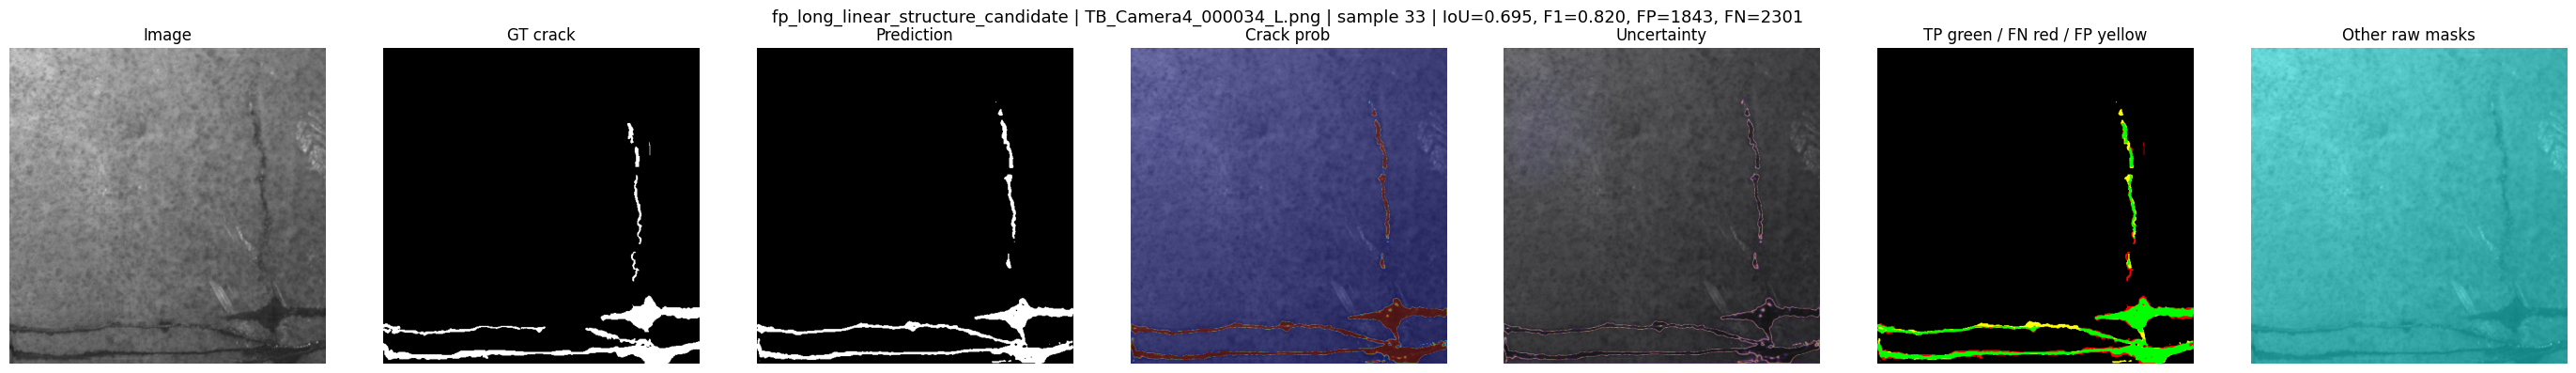

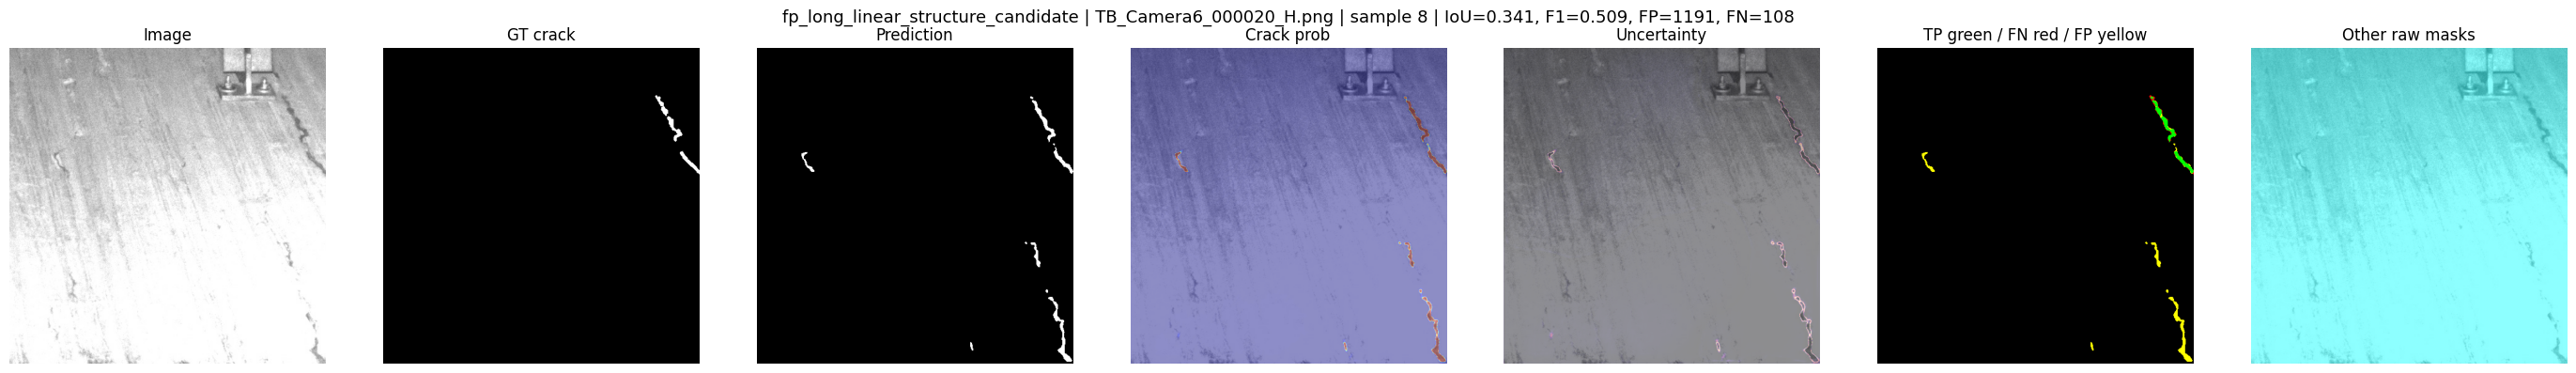

In [17]:
PREVIEW_FAILURE_TYPE = 'fp_long_linear_structure_candidate'
PREVIEW_N = 2

preview_rows = representative_df[
    representative_df['failure_type'].eq(PREVIEW_FAILURE_TYPE)
].dropna(subset=['sample_id']).head(PREVIEW_N)

for _, row in preview_rows.iterrows():
    save_failure_panel(
        sample_id=int(row['sample_id']),
        failure_type=row['failure_type'],
        rank_within_type=row['rank_within_type'],
        show=True,
    )

## 9. How to Interpret This Scientifically

You do not need to manually label every image. A defensible workflow is:

1. **Automatic screening:** use FP/FN, probability, uncertainty, raw-mask overlap, brightness, edge strength, and component geometry.
2. **Candidate taxonomy:** assign proposed labels such as `fp_overlaps_other_defect_mask` or `fp_edge_or_seam_candidate`.
3. **Human validation:** manually inspect a small balanced subset of top examples per type.
4. **Report with evidence:** show representative images and count how many candidate cases each signal found.

This is more scientific than pure manual labeling because the candidate labels come from measurable rules. It is also more honest than pretending the rules are perfect, because the final report examples are manually validated.